In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris-dataset-new-project/Iris.csv


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## **1.Dataset Loading**

In [3]:
df=pd.read_csv("/kaggle/input/iris-dataset-new-project/Iris.csv")
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
103,6.3,2.9,5.6,1.8,Iris-virginica
70,5.9,3.2,4.8,1.8,Iris-versicolor
44,5.1,3.8,1.9,0.4,Iris-setosa
109,7.2,3.6,6.1,2.5,Iris-virginica
41,4.5,2.3,1.3,0.3,Iris-setosa


In [4]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [5]:
le=LabelEncoder()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

## **2.EDA**

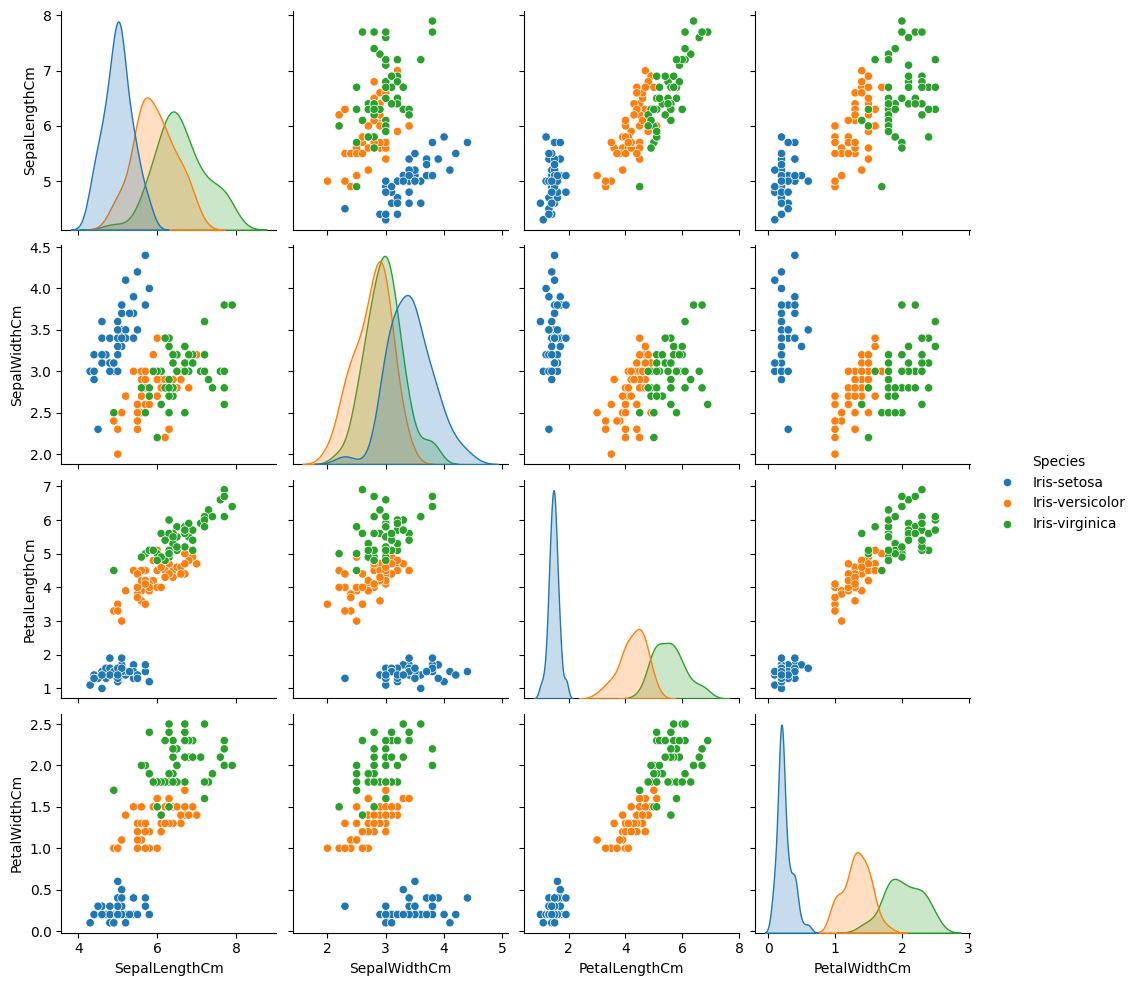

In [8]:
sns.pairplot(df,hue='Species')

## Correlation HeatMap

In [9]:
corr_matrix = df.drop('Species', axis=1).corr()
corr_matrix


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


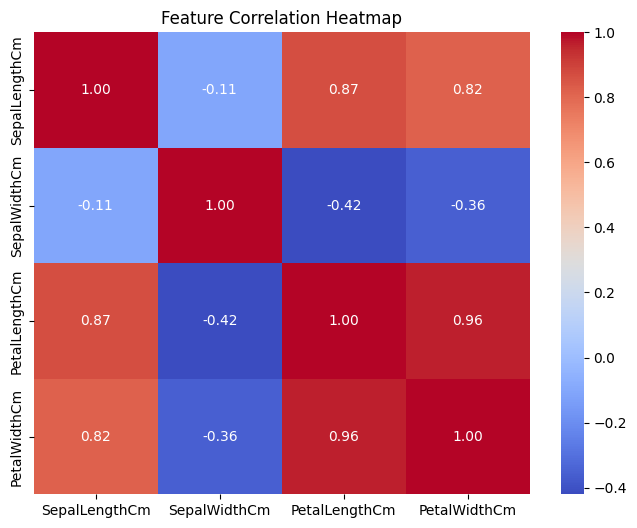

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.show()


**The correlation heatmap shows a strong positive correlation between petal length and petal width, indicating potential multicollinearity. However, this does not significantly impact model performance due to the small dataset size and robustness of selected classifiers. Sepal width exhibits weak and negative correlations with other features, suggesting lower predictive importance. Overall, petal features are the most informative for species classification, and no features were dropped based on correlation analysis.**

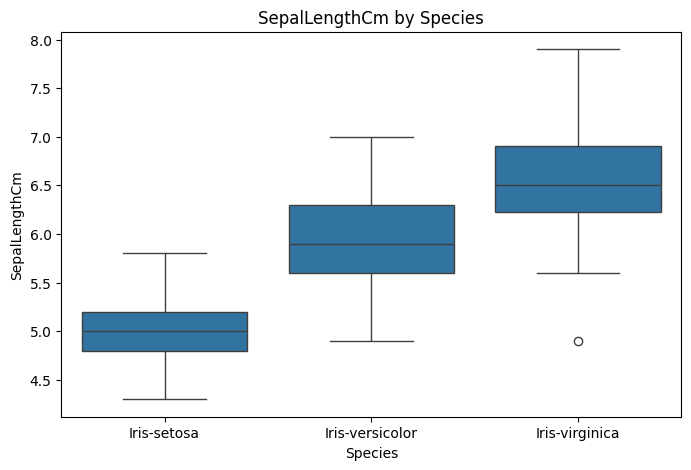

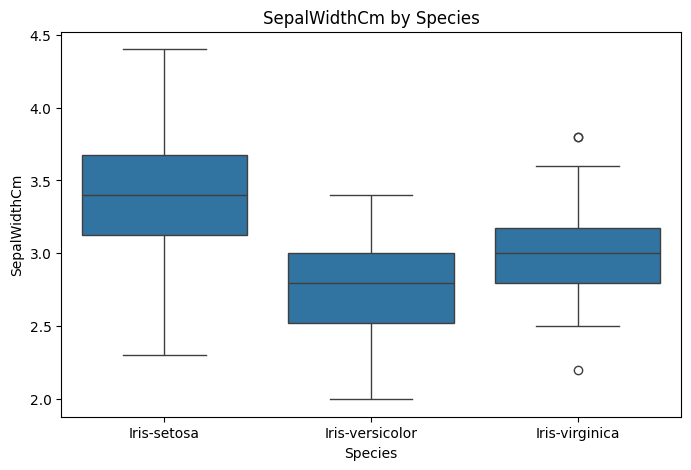

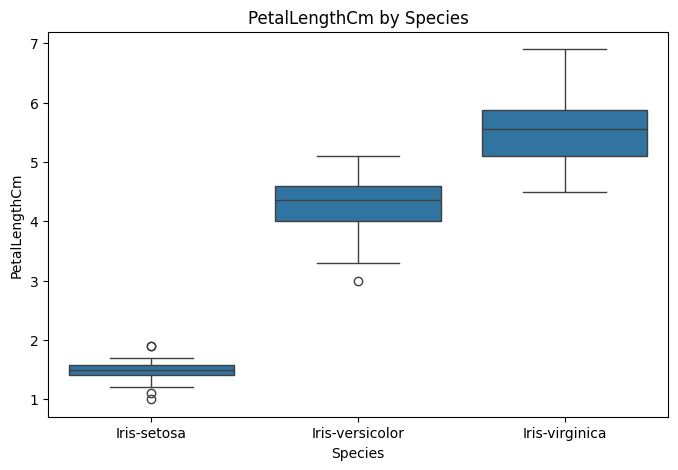

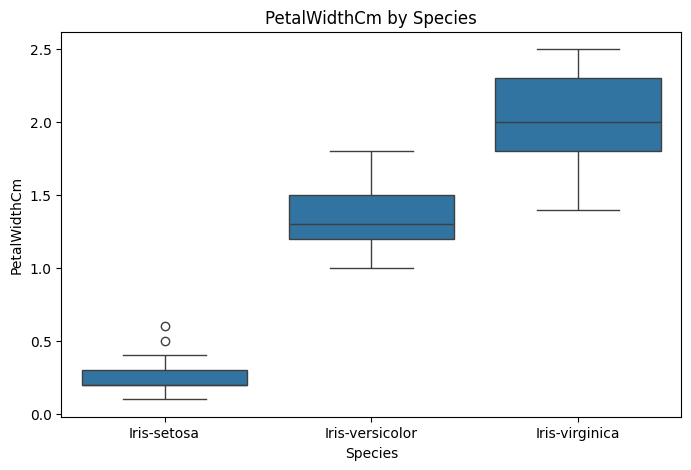

In [11]:
## Boxplot
features = df.columns[:-1]

for feature in features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Species', y=feature, data=df)
    plt.title(f"{feature} by Species")
    plt.show()


**Boxplot analysis indicates that petal length and petal width are the most important features for species classification, as they show clear separation and minimal overlap among classes. Sepal length provides moderate discriminatory power, while sepal width exhibits significant overlap across species, making it the least important feature. These observations suggest that petal-based features contribute most effectively to classification performance.**

In [12]:
df['Species']=le.fit_transform(df['Species'])

In [13]:
df.sample(10)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
85,6.0,3.4,4.5,1.6,1
4,5.0,3.6,1.4,0.2,0
22,4.6,3.6,1.0,0.2,0
111,6.4,2.7,5.3,1.9,2
145,6.7,3.0,5.2,2.3,2
115,6.4,3.2,5.3,2.3,2
56,6.3,3.3,4.7,1.6,1
86,6.7,3.1,4.7,1.5,1
60,5.0,2.0,3.5,1.0,1
133,6.3,2.8,5.1,1.5,2


## **3. Dataset Splitting**

In [14]:
X=df.drop(columns=['Species'])

In [15]:
X.shape

(150, 4)

In [16]:
y=df['Species']
y.shape

(150,)

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=43)

In [18]:
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)


In [19]:
X_train_scaled[0]

array([-0.23188906, -0.68802813,  0.39697298,  0.08814647])

## **4. Model Building**

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.pipeline import Pipeline

lr=LogisticRegression(max_iter=200,penalty=None,solver='lbfgs')
knn=KNeighborsClassifier(n_neighbors=10,n_jobs=-1)

In [21]:
models={'Logistic_Regression':LogisticRegression(max_iter=200,penalty=None,solver='lbfgs'),
        'K Neighbors Classifier':KNeighborsClassifier(n_neighbors=5,n_jobs=-1),
        'SVC':SVC(kernel='rbf',verbose=True),
        'Decision Tree Classifier':DecisionTreeClassifier(splitter='best',criterion='log_loss',max_depth=5),
        'Random Forest Classifier':RandomForestClassifier(criterion='log_loss',n_estimators=100,max_depth=4)
}

In [22]:
models.items()

dict_items([('Logistic_Regression', LogisticRegression(max_iter=200, penalty=None)), ('K Neighbors Classifier', KNeighborsClassifier(n_jobs=-1)), ('SVC', SVC(verbose=True)), ('Decision Tree Classifier', DecisionTreeClassifier(criterion='log_loss', max_depth=5)), ('Random Forest Classifier', RandomForestClassifier(criterion='log_loss', max_depth=4))])

In [23]:
X_train_scaled

array([[-0.23188906, -0.68802813,  0.39697298,  0.08814647],
       [-0.47659611, -1.15713821,  0.3397958 , -0.04221099],
       [-0.23188906, -1.15713821, -0.1747988 , -0.3029259 ],
       [ 0.99164619,  0.015637  ,  0.3397958 ,  0.21850393],
       [ 0.50223209,  0.48474709,  0.51132734,  0.47921885],
       [ 0.50223209, -1.39169325,  0.6256817 ,  0.34886139],
       [-0.10953554, -0.92258317,  0.05390991, -0.04221099],
       [ 0.99164619,  0.015637  ,  0.51132734,  0.34886139],
       [-0.10953554, -0.92258317,  0.74003605,  0.87029123],
       [-0.59894964,  0.71930213, -1.20398802, -1.34578558],
       [-1.21071726, -1.39169325,  0.39697298,  0.60957631],
       [ 2.21518144, -0.21891804,  1.31180784,  1.39172106],
       [-1.08836374,  0.95385717, -1.26116519, -0.82435574],
       [ 0.13517151, -0.92258317,  0.74003605,  0.47921885],
       [ 0.62458561,  0.25019205,  0.85439041,  1.39172106],
       [-0.10953554, -1.15713821,  0.11108709, -0.04221099],
       [-1.08836374,  1.

In [24]:
results=[]
pred_values=[]
for name, model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model_name':name,
                    'Accuracy Score':acc
                   }
                  )
    
    

    

[LibSVM]*
optimization finished, #iter = 26
obj = -3.164172, rho = -0.009242
nSV = 10, nBSV = 2
*
optimization finished, #iter = 30
obj = -2.810821, rho = 0.122995
nSV = 12, nBSV = 1
*
optimization finished, #iter = 31
obj = -20.569228, rho = -0.042005
nSV = 33, nBSV = 26
Total nSV = 44


In [25]:
print(results)

[{'Model_name': 'Logistic_Regression', 'Accuracy Score': 1.0}, {'Model_name': 'K Neighbors Classifier', 'Accuracy Score': 0.9555555555555556}, {'Model_name': 'SVC', 'Accuracy Score': 0.9777777777777777}, {'Model_name': 'Decision Tree Classifier', 'Accuracy Score': 0.9333333333333333}, {'Model_name': 'Random Forest Classifier', 'Accuracy Score': 0.9111111111111111}]


##  **5. Model Results**

In [26]:

results_df = pd.DataFrame(results).sort_values(by="Accuracy Score", ascending=False)
results_df

,Model_name,Accuracy Score
0,Logistic_Regression,1.000000
2,SVC,0.977778
1,K Neighbors Classifier,0.955556
3,Decision Tree Classifier,0.933333
4,Random Forest Classifier,0.911111


## **6. Cross Validation**

In [27]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=200, penalty=None, solver='lbfgs'))
    ]),
    
    'K Neighbors Classifier': Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]),
    
    'Support Vector Classifier': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf'))
    ]),
    
    'Decision Tree Classifier': DecisionTreeClassifier(
        splitter='best',
        criterion='log_loss',
        max_depth=5,
        random_state=42
    ),
    
    'Random Forest Classifier': RandomForestClassifier(
        criterion='log_loss',
        n_estimators=100,
        max_depth=4,
        random_state=42
    )
}

In [28]:
cv_results=[]
for name, model in models.items():
    cv_scores = np.mean(cross_val_score(model, X, y, cv=5, scoring='accuracy'))
    
    cv_results.append({
        "Model": name,
        "Mean Accuracy": np.round(cv_scores,3)
        
    })

In [29]:
cv_df_cross_val=pd.DataFrame(cv_results).sort_values(by='Mean Accuracy',ascending=False)
print(cv_df_cross_val)

                       Model  Mean Accuracy
0        Logistic Regression          0.973
2  Support Vector Classifier          0.967
4   Random Forest Classifier          0.967
1     K Neighbors Classifier          0.960
3   Decision Tree Classifier          0.953


In [30]:
cv_df_cross_val

,Model,Mean Accuracy
0,Logistic Regression,0.973
2,Support Vector Classifier,0.967
4,Random Forest Classifier,0.967
1,K Neighbors Classifier,0.960
3,Decision Tree Classifier,0.953


## **Conclusion - Logistic Regression shows the highest accuracy**

Random Forest and SVC perform comparably

Decision Tree performs the weakest

Confirms numerical cross-validation results** 

In [31]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,
                    y_pred)


In [32]:
cm

array([[15,  0,  0],
       [ 0, 16,  1],
       [ 0,  3, 10]])

In [33]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
                            )

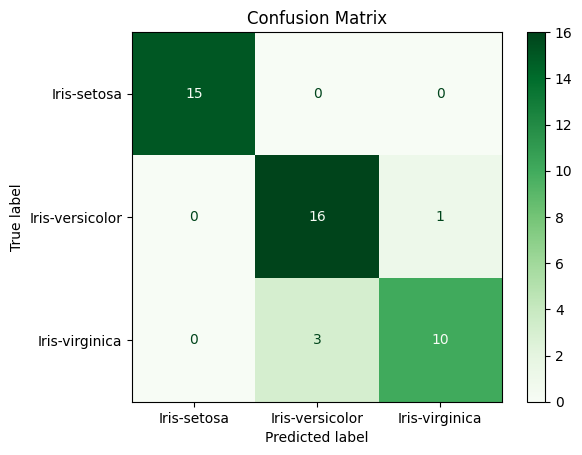

In [34]:
disp.plot(cmap='Greens')
plt.title('Confusion Matrix')
plt.show()

##  **cmap supported values are**
 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'crest', 'crest_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'flare', 'flare_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'icefire', 'icefire_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'mako', 'mako_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'rocket', 'rocket_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'vlag', 'vlag_r', 'winter', 'winter_r'